In [50]:
import numpy as np
from numpy import round
import matplotlib.pyplot as plt
from tqdm import tqdm

In [51]:
beta = 1.

def gamma_k(_kx, _ky):
    return (np.cos(_kx) + np.cos(_ky))/2

def gamma2_k(_kx, _ky):
    return 1/4 * (np.cos(_kx) + np.cos(_ky))**2

def a_func(t, n, delta = 1., lamb = 0.):
    return 2 * (delta + t - 2 * n * (t/2 + lamb * delta))

def b_func(t, n, I, delta = 1., lamb = 0.):
    return 2 * (1 - 2 * n + I + t * (t/2 + beta * lamb * delta) )

def get_bog_pars(t, n, I, _kx, _ky, delta = 1., lamb = 0.):
    a = a_func(t, n, delta, lamb)
    b = b_func(t, n, I, delta, lamb)

    wk = np.abs(np.sqrt(a**2 - b**2 * gamma2_k(_kx, _ky) + 0j))
    
    alpha_plus = np.sqrt(1/2 * (a/wk + 1) + 0j)
    alpha_minus = np.sign(gamma_k(_kx, _ky)) * np.sqrt(1/2 * (a/wk - 1) + 0j)

    return a, b, wk, alpha_plus, alpha_minus

def t(b, wk, gamma2k, N):
    return np.abs(b)/N * np.real(np.sum(gamma2k / wk))

def n(a, wk, N):
    return 1/(2*N) * np.sum(np.abs(a/wk - 1))

def I(a_plus_k, a_minus_k, a_plus_q, a_minus_q, kx, ky, qx, qy, N):
    return 1/(2*N**2) * np.sum(np.real(a_plus_k * a_minus_k * np.conj(a_plus_q * a_minus_q)) * 2 * gamma_k(kx + qx, ky + qy)
                         + (np.abs(a_minus_k)**2 * np.abs(a_plus_q)**2) * 2 * gamma_k(kx - qx, ky - qy))

In [52]:
def SC_MF(delta = 1., lamb = 0., leapfrog : bool = False, k_bins = 50, n_steps = 10, disable_tqdm = False):
    # strating parameters
    n_old = .2
    t_old = .2
    I_old = n_old**2 + 1/4 * t_old**2

    N = k_bins**2
    k = np.linspace(-np.pi, np.pi, k_bins, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')
    kx, ky, qx, qy = np.meshgrid(k, k, k, k, indexing = 'ij')

    t_array = []
    n_array = []
    I_array = []

    for _ in tqdm(range(n_steps), disable = disable_tqdm):
        # get general parameters
        a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, px, py, delta, lamb)
        gamma2k = gamma2_k(px, py)

        # get new t
        t_new = t(b, wk, gamma2k, N)

        # if leapfrog -> update t and delta_k
        if leapfrog:
            t_old = t_new
            a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, px, py, delta, lamb)

        # get new n
        n_new = n(a, wk, N)

        # if leapfrog -> update n
        if leapfrog:
            n_old = n_new

        # to satisfy both methods, it is better to calculate q here
        a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, kx, ky, delta, lamb)
        a, b, wq, apq, amq = get_bog_pars(t_old, n_old, I_old, qx, qy, delta, lamb)

        # get new I
        I_new = I(apk, amk, apq, amq, kx, ky, qx, qy, N)

        t_old = t_new
        n_old = n_new
        I_old = I_new

        t_array.append(t_old)
        n_array.append(n_old)
        I_array.append(I_old)
        
    return np.array(t_array), np.array(n_array), np.array(I_array), range(n_steps)

In [56]:
def disp(n, t, I, delta = 1., l = 0., _print = True):

    ak = a_func(t, n, delta, l)
    bk = b_func(t, n, I, delta, l)

    #print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')

    const = +1

    if bk**2 > ak**2:
        if _print:
            print('IMAGINARY')
        const = -1
    
    gap_g = const * np.sqrt(np.abs(np.abs(ak)**2 - np.abs(bk)**2))
    gap_x = np.sqrt(np.abs(ak)**2)

    if _print:
        print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')
        print(f'Gap at G point: {round(gap_g, 3)}')
        print(f'Gap at X point: {round(gap_x, 3)}')

    return gap_g, gap_x

In [ ]:
def get_mf(delta = 1., lamb = 0., k_bins = 50, froggie = True, plot_changes : bool = False, n_steps = 20, _print = True):
    ts, ns, Is, steps = SC_MF(delta, lamb, leapfrog=froggie, k_bins=k_bins, n_steps = n_steps, disable_tqdm = not _print)
    fin_t = ts[-1]
    fin_n = ns[-1]
    fin_I = Is[-1]

    if _print:
        print(f'Final t = {round(fin_t, 5)}')
        print(f'Final n = {round(fin_n, 5)}')
        print(f'Final I = {round(fin_I, 5)}')

    if plot_changes:
        plt.scatter(steps[1:], abs(ts[1:] - np.roll(ts[:-1], 1)), label = 't')
        plt.scatter(steps[1:], abs(ns[1:] - np.roll(ns[:-1], 1)), label = 'n')
        plt.scatter(steps[1:], abs(Is[1:] - np.roll(Is[:-1], 1)), label = 'I')
        plt.yscale('log')
        plt.show()

    g, x = disp(fin_n, fin_t, fin_I, delta, lamb, _print = _print)

    return g, x, fin_n, fin_t, fin_I

In [ ]:
gapgs = []
gapxs = []

l_i = 0.
l_f = 1.
steps = 51
k_bins = 75

lambs = np.linspace(l_i, l_f, steps)
delta = 1.

for l in tqdm(lambs):
    #print(f'Bin size {b} started')
    g, x, n, t, i = get_mf(delta, l, k_bins = k_bins, plot_changes=False, _print = False)
    gapgs.append(g)
    gapxs.append(x)

matrix = np.zeros((len(lambs), 3))
matrix[:, 0] = lambs
matrix[:, 1] = gapgs
matrix[:, 2] = gapxs
matrix[:, 3] = n
matrix[:, 4] = t
matrix[:, 5] = i

np.savetxt(rf'MF/data/HF_sc_mf_with_I_d_{round(float(delta), 4)}_lamb_var_{l_i}-{l_f}_steps_{steps}_k_bins_{k_bins}.txt', matrix, fmt=[ '%.3f', '%.5f', '%.5f' ],
           header = "lambda \t Gap_Gamma \t Gap_X", delimiter="\t")

100%|██████████| 51/51 [59:23<00:00, 69.88s/it]


[ 1.55925831 -1.24601424  1.52962965]


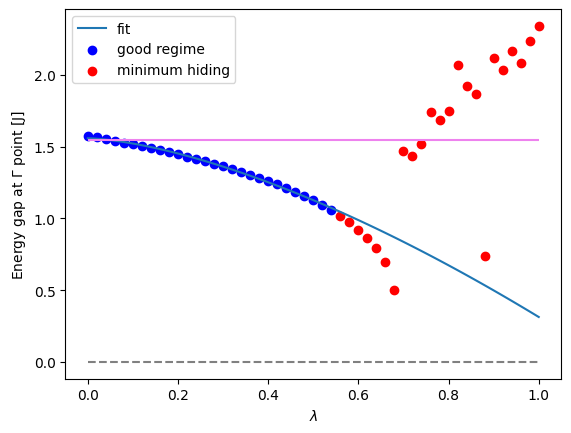

In [81]:
def func(x, params):
    a, b, c = params
    return a + x**(c) * b

l_ind = np.argmin(np.abs(lambs - .56))

def cost(params):
    return np.sum(np.square(func(lambs[:l_ind], params) - np.abs(gapgs[:l_ind])))

from scipy.optimize import minimize

fun = minimize(cost, (1.55, -1.5, 2.))
print(fun.x)

x = np.linspace(0., 1., 101)
plt.plot(x, func(x, fun.x), label = 'fit')

plt.scatter(lambs[:l_ind], np.abs(gapgs[:l_ind]), color = 'blue', label = 'good regime')
plt.scatter(lambs[l_ind:], np.abs(gapgs[l_ind:]), color = 'red', label = 'minimum hiding')
plt.hlines([0.], 0, 1., 'gray', '--')
plt.hlines([1.548], 0, 1., 'violet', '-')
plt.ylabel(r'Energy gap at $\Gamma$ point [J]')
plt.xlabel(r'$\lambda$')
#plt.xlim([0., .7])
plt.legend()
plt.show()

100%|██████████| 6/6 [00:19<00:00,  3.22s/it]


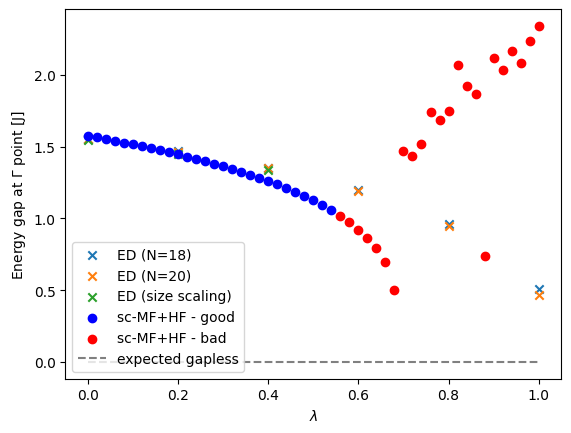

In [86]:
ed_lambs = np.arange(0., 1.1, .2)

from clusters_lattice_fast import SpinConfiguration

for n_spins in [18, 20]:
    gapg_ED = []
    
    sc = SpinConfiguration(N = n_spins, delta = 1., lamb = 0, lowest_eignstates=2)
    sc_minus = SpinConfiguration(N = n_spins, magnon_number=int(n_spins/2) + 1, delta = 1., lamb = 0, lowest_eignstates=2)

    for l in tqdm(ed_lambs):
        sc.generate_hamiltonian(lamb = l)
        sc.get_eigva_eigve(2)
        min_e = sc.gs_energy

        sc_minus.generate_hamiltonian(lamb = l)
        sc_minus.get_eigva_eigve(2)
        min_e_minus = sc_minus.gs_energy

        gapg_ED.append(min_e_minus - min_e)

    plt.scatter(ed_lambs, gapg_ED, label = f'ED (N={n_spins})', marker = 'x')

scaled_lamb = [0, .2, .4]
gaps_size_scaling = [1.548, 1.4525, 1.33486]

plt.scatter(scaled_lamb, gaps_size_scaling, label = f'ED (size scaling)', marker = 'x')

plt.scatter(lambs[:l_ind], np.abs(gapgs[:l_ind]), color = 'blue', label = 'sc-MF+HF - good')
plt.scatter(lambs[l_ind:], np.abs(gapgs[l_ind:]), color = 'red', label = 'sc-MF+HF - bad')

#plt.scatter(lambs, np.abs(gapgs), label = 'sc-MF+HF')
#plt.scatter(lambs, np.abs(gapgs), label = 'sc-MF+HF')
plt.hlines([0.], 0, 1., 'gray', '--', label=r'expected gapless')
#plt.hlines([1.548], 0, 1., 'violet', '--', label='ED gap for $\lambda$ = 0')
plt.ylabel(r'Energy gap at $\Gamma$ point [J]')
plt.xlabel(r'$\lambda$')
#plt.xlim([0., .7])
plt.legend()
plt.show()

[ 2.45432464 -0.07232162  1.14303699]


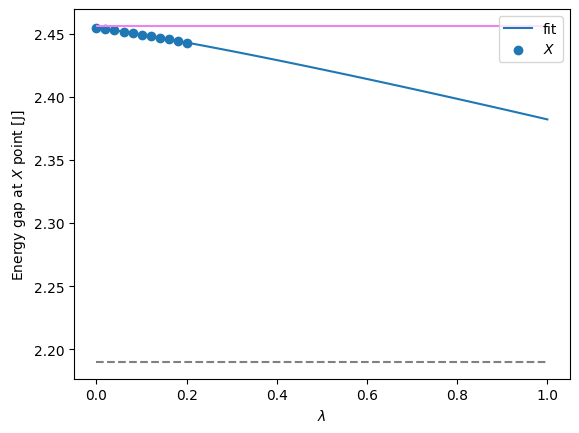

In [36]:
def func(x, params):
    a, b, c = params
    return a + x**(c) * b

def cost(params):
    return np.sum(np.square(func(lambs, params) - np.abs(gapxs)))

from scipy.optimize import minimize

fun = minimize(cost, (2.456, -.1, 2.))
print(fun.x)

x = np.linspace(0., 1., 101)
plt.plot(x, func(x, fun.x), label = 'fit')

plt.scatter(lambs, np.abs(gapxs), label = r'$X$')
plt.hlines([2.19], 0, 1., 'gray', '--')
plt.hlines([2.456], 0, 1., 'violet', '-')
plt.ylabel(r'Energy gap at $X$ point [J]')
plt.xlabel(r'$\lambda$')
plt.legend()
plt.show()